# R-CNN Cell Classifier — Local Dataset

Trains an **R-CNN classification model** using cell crops extracted from the
YOLOv8 local dataset bounding box annotations.

## How it works
1. Reads YOLO-format annotations from the local dataset
2. Crops each annotated bounding box from the source images
3. Labels each crop by its annotation class
4. Trains a ResNet-18 based R-CNN classifier on these crops

## Output
- `scd_rcnn_local_classifier.pt`

In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import os
import shutil
import copy
import random
import yaml
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [2]:
# ============================================================
# CELL 2: Configuration
# ============================================================

DATASET_ROOT = '/content/drive/MyDrive/SCD/SCD_LocalDataset'
CROPS_DIR = '/content/drive/MyDrive/SCD/scd_local_crops'  # Extracted crops
MODEL_SAVE_DIR = '/content/drive/MyDrive/SCD'

INPUT_SIZE    = 224
BATCH_SIZE    = 16            # Small batches for small dataset
NUM_WORKERS   = 2
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 5e-3
EPOCHS        = 60
PATIENCE      = 15
LABEL_SMOOTHING = 0.15
MIXUP_ALPHA   = 0.3

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Read class names from data.yaml
data_yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config.get('names', [])
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Configuration loaded.')

Classes (1): ['Sickle']
Configuration loaded.


In [4]:
# ============================================================
# CELL 3: Extract Cell Crops from Annotations
# ============================================================
# Read each YOLO annotation, crop the bounding box region from
# the image, and save to class-specific folders.

def extract_crops(dataset_root, output_dir):
    """Extract cell crops from YOLO annotations."""
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)

    stats = {}

    for split in ['train', 'valid', 'test']:
        # Map 'valid' -> 'val' in output for consistency
        out_split = 'val' if split == 'valid' else split

        img_dir = os.path.join(dataset_root, split, 'images')
        lbl_dir = os.path.join(dataset_root, split, 'labels')

        if not os.path.isdir(img_dir):
            print(f'  Skipping {split}: no images dir')
            continue

        # Create output folders for each class
        for cls_name in CLASS_NAMES:
            os.makedirs(os.path.join(output_dir, out_split, cls_name), exist_ok=True)

        split_count = 0

        for img_file in sorted(os.listdir(img_dir)):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(img_dir, img_file)
            lbl_file = os.path.splitext(img_file)[0] + '.txt'
            lbl_path = os.path.join(lbl_dir, lbl_file)

            if not os.path.exists(lbl_path):
                continue

            img = Image.open(img_path).convert('RGB')
            w_img, h_img = img.size

            with open(lbl_path) as f:
                for line_idx, line in enumerate(f):
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue

                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])

                    # Convert normalized coords to pixel coords
                    x1 = int((cx - bw / 2) * w_img)
                    y1 = int((cy - bh / 2) * h_img)
                    x2 = int((cx + bw / 2) * w_img)
                    y2 = int((cy + bh / 2) * h_img)

                    # Clamp to image bounds
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w_img, x2)
                    y2 = min(h_img, y2)

                    # Skip tiny crops
                    if (x2 - x1) < 10 or (y2 - y1) < 10:
                        continue

                    # Add padding (10% of box size) for context
                    pad_w = int((x2 - x1) * 0.1)
                    pad_h = int((y2 - y1) * 0.1)
                    x1 = max(0, x1 - pad_w)
                    y1 = max(0, y1 - pad_h)
                    x2 = min(w_img, x2 + pad_w)
                    y2 = min(h_img, y2 + pad_h)

                    crop = img.crop((x1, y1, x2, y2))

                    cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'class_{cls_id}'
                    base_name = os.path.splitext(img_file)[0]
                    crop_name = f'{base_name}_box{line_idx}.jpg'
                    crop_path = os.path.join(output_dir, out_split, cls_name, crop_name)

                    crop.save(crop_path, quality=95)
                    split_count += 1

        stats[out_split] = split_count
        print(f'  {out_split}: {split_count} crops extracted')

    return stats


print('Extracting cell crops from annotations...')
crop_stats = extract_crops(DATASET_ROOT, CROPS_DIR)

# Show per-class counts
print('\nCrop counts per class per split:')
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(CROPS_DIR, split)
    if not os.path.isdir(split_dir):
        continue
    for cls_name in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls_name)
        if os.path.isdir(cls_dir):
            n = len(os.listdir(cls_dir))
            print(f'  {split}/{cls_name}: {n} crops')

Extracting cell crops from annotations...
  train: 27 crops extracted
  val: 2 crops extracted
  test: 3 crops extracted

Crop counts per class per split:
  train/Sickle: 27 crops
  val/Sickle: 2 crops
  test/Sickle: 3 crops


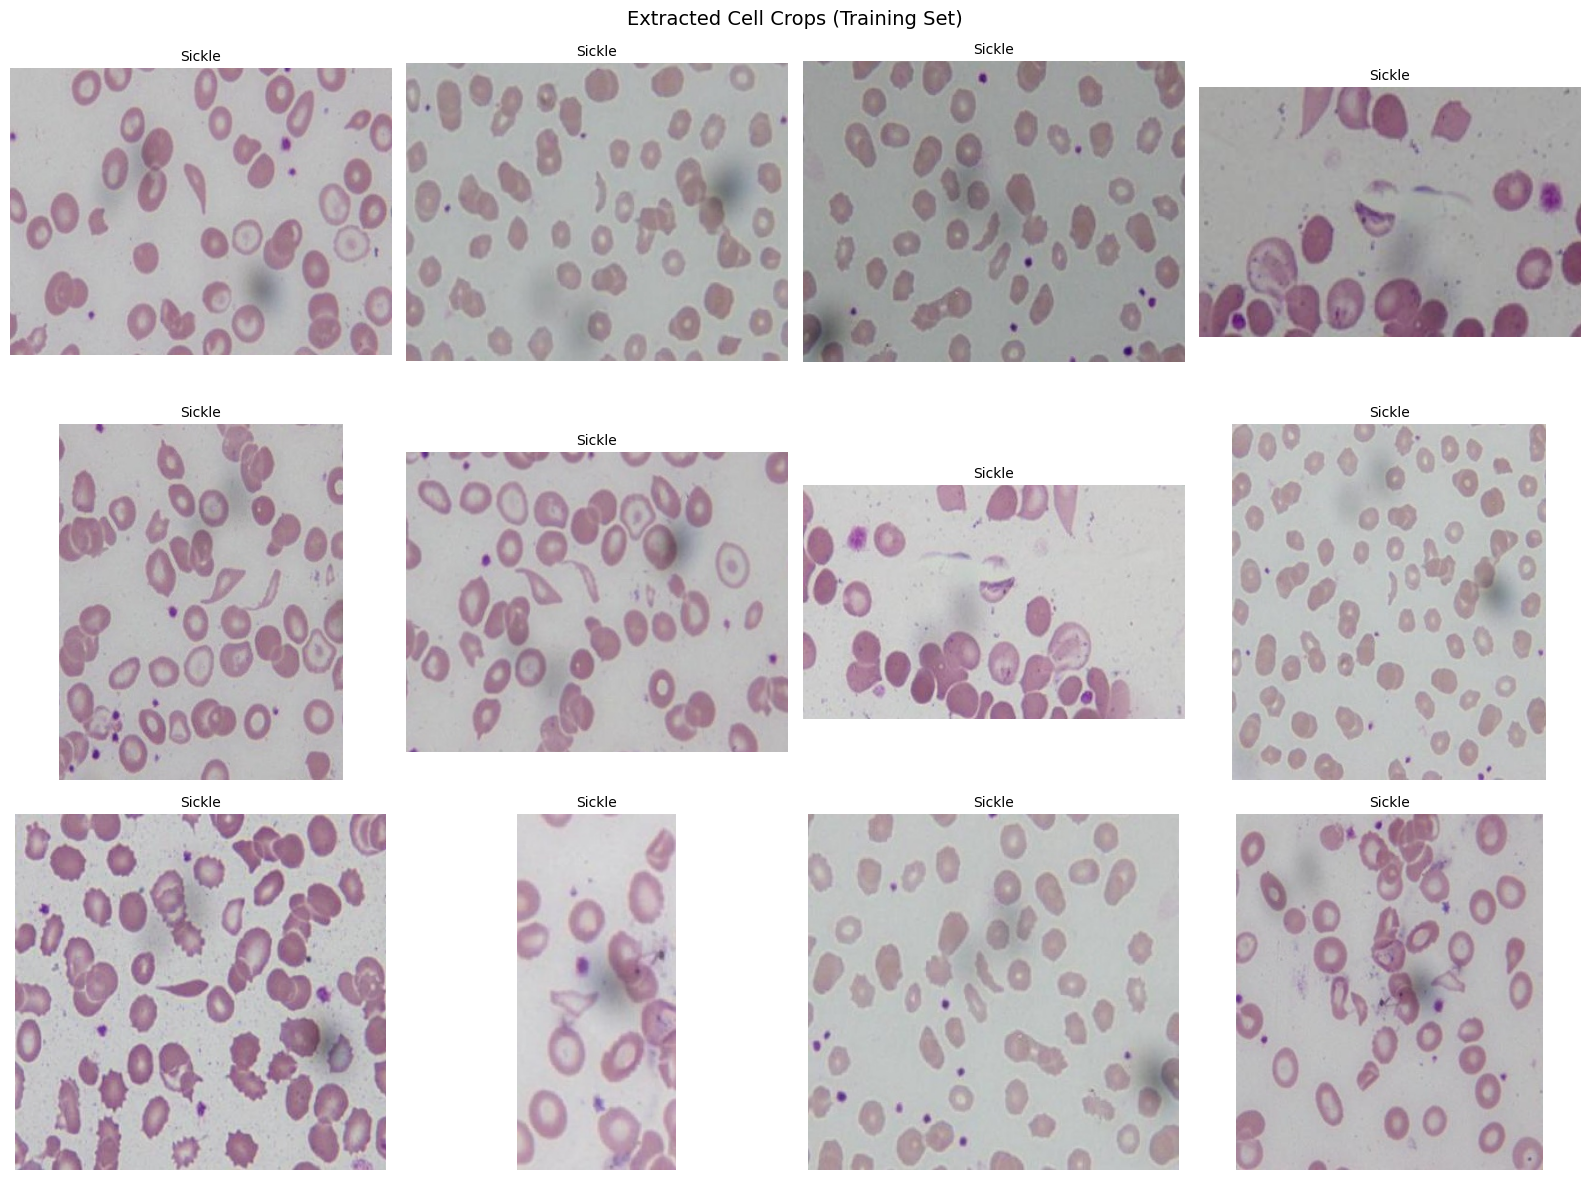

In [5]:
# ============================================================
# CELL 4: Visualize Extracted Crops
# ============================================================

train_crop_dir = os.path.join(CROPS_DIR, 'train')
all_crops = []
for cls_name in sorted(os.listdir(train_crop_dir)):
    cls_dir = os.path.join(train_crop_dir, cls_name)
    if os.path.isdir(cls_dir):
        for fn in os.listdir(cls_dir):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_crops.append((os.path.join(cls_dir, fn), cls_name))

samples = random.sample(all_crops, min(12, len(all_crops)))
rows = (len(samples) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = np.array(axes).flatten()

for i, (path, cls) in enumerate(samples):
    img = Image.open(path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Extracted Cell Crops (Training Set)', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 5: Data Transforms & DataLoaders
# ============================================================

from torchvision import datasets

TRAIN_DIR = os.path.join(CROPS_DIR, 'train')
VAL_DIR   = os.path.join(CROPS_DIR, 'val')
TEST_DIR  = os.path.join(CROPS_DIR, 'test')

# Heavy augmentation for tiny dataset
train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE + 32, INPUT_SIZE + 32)),
    transforms.RandomCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.15, 0.15), scale=(0.8, 1.2), shear=10),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

eval_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transforms)

print(f'ImageFolder class_to_idx: {train_dataset.class_to_idx}')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

# Class weights
train_labels = [label for _, label in train_dataset.samples]
label_counts = Counter(train_labels)
total = sum(label_counts.values())
n_cls = len(train_dataset.classes)
class_weights = torch.tensor(
    [total / (n_cls * label_counts.get(i, 1)) for i in range(n_cls)],
    dtype=torch.float32
).to(DEVICE)
print(f'Label distribution: {dict(label_counts)}')
print(f'Class weights: {class_weights.tolist()}')

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

ImageFolder class_to_idx: {'Sickle': 0}
Train: 27, Val: 2, Test: 3
Label distribution: {0: 27}
Class weights: [1.0]
Batches — Train: 1, Val: 1, Test: 1


In [7]:
# ============================================================
# CELL 6: Define R-CNN Classifier Model
# ============================================================

class RCNNCellClassifier(nn.Module):
    """
    R-CNN classification head for sickle cell detection.
    Regularized version — frozen backbone + compact FC head.
    """

    def __init__(self, num_classes=2, backbone='resnet18', pretrained=True,
                 freeze_backbone=True):
        super().__init__()

        if backbone == 'resnet18':
            base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        elif backbone == 'resnet34':
            base = models.resnet34(weights=models.ResNet34_Weights.DEFAULT if pretrained else None)
        elif backbone == 'resnet50':
            base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        else:
            raise ValueError(f'Unsupported backbone: {backbone}')

        self.features = nn.Sequential(*list(base.children())[:-2])
        feat_dim = base.fc.in_features

        if freeze_backbone:
            for i, child in enumerate(self.features.children()):
                if i <= 5:
                    for param in child.parameters():
                        param.requires_grad = False

        self.roi_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.6),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.features(x)
        pooled = self.roi_pool(features)
        logits = self.classifier(pooled)
        return logits


model = RCNNCellClassifier(
    num_classes=n_cls,
    backbone='resnet18',
    pretrained=True,
    freeze_backbone=True
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: RCNNCellClassifier')
print(f'  Total params:     {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')
print(f'  Frozen:           {(total_params - trainable_params):,}')
print(f'  Classes: {n_cls} ({train_dataset.classes})')

dummy = torch.randn(2, 3, INPUT_SIZE, INPUT_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'  Output shape: {out.shape}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Model: RCNNCellClassifier
  Total params:     13,307,713
  Trainable params: 12,624,641
  Frozen:           683,072
  Classes: 1 (['Sickle'])
  Output shape: torch.Size([2, 1])


In [8]:
# ============================================================
# CELL 7: Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=1, eta_min=1e-6
)

print('Training setup:')
print(f'  Loss: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})')
print(f'  Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'  Scheduler: CosineAnnealing (T_0=15)')
print(f'  Mixup alpha: {MIXUP_ALPHA}')

Training setup:
  Loss: CrossEntropyLoss (label_smoothing=0.15)
  Optimizer: AdamW (lr=0.0003, wd=0.005)
  Scheduler: CosineAnnealing (T_0=15)
  Mixup alpha: 0.3


In [9]:
# ============================================================
# CELL 8: Training Loop (with Mixup)
# ============================================================

def mixup_data(x, y, alpha=0.3):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam


def train_one_epoch(model, loader, criterion, optimizer, device, mixup_alpha=0.0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if mixup_alpha > 0:
            mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            optimizer.zero_grad()
            outputs = model(mixed_images)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        with torch.no_grad():
            clean_out = model(images)
            _, predicted = clean_out.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


# --- Train ---
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_model_state = None
epochs_no_improve = 0

print(f'Training for {EPOCHS} epochs...')
print(f'{"Ep":>4} | {"TrLoss":>8} | {"TrAcc":>7} | {"VlLoss":>8} | {"VlAcc":>7} | {"LR":>10} | Status')
print('-' * 78)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, MIXUP_ALPHA)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(epoch)
    lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['lr'].append(lr)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        status = f'* BEST ({vl_acc:.4f})'
    else:
        epochs_no_improve += 1
        status = f'  ({epochs_no_improve}/{PATIENCE})'

    print(f'{epoch:>4} | {tr_loss:>8.4f} | {tr_acc:>6.4f} | {vl_loss:>8.4f} | {vl_acc:>6.4f} | {lr:>10.6f} | {status}')

    if epochs_no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

if best_model_state:
    model.load_state_dict(best_model_state)
    print(f'Restored best weights (val_acc={best_val_acc:.4f})')

Training for 60 epochs...
  Ep |   TrLoss |   TrAcc |   VlLoss |   VlAcc |         LR | Status
------------------------------------------------------------------------------
   1 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000297 | * BEST (1.0000)
   2 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000287 |   (1/15)
   3 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000271 |   (2/15)
   4 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000251 |   (3/15)
   5 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000225 |   (4/15)
   6 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000197 |   (5/15)
   7 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000166 |   (6/15)
   8 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000135 |   (7/15)
   9 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000104 |   (8/15)
  10 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000076 |   (9/15)
  11 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000050 |   (10/15)
  12 |   0.0000 | 1.0000 |   0.0000 | 1.0000 |   0.000030 |

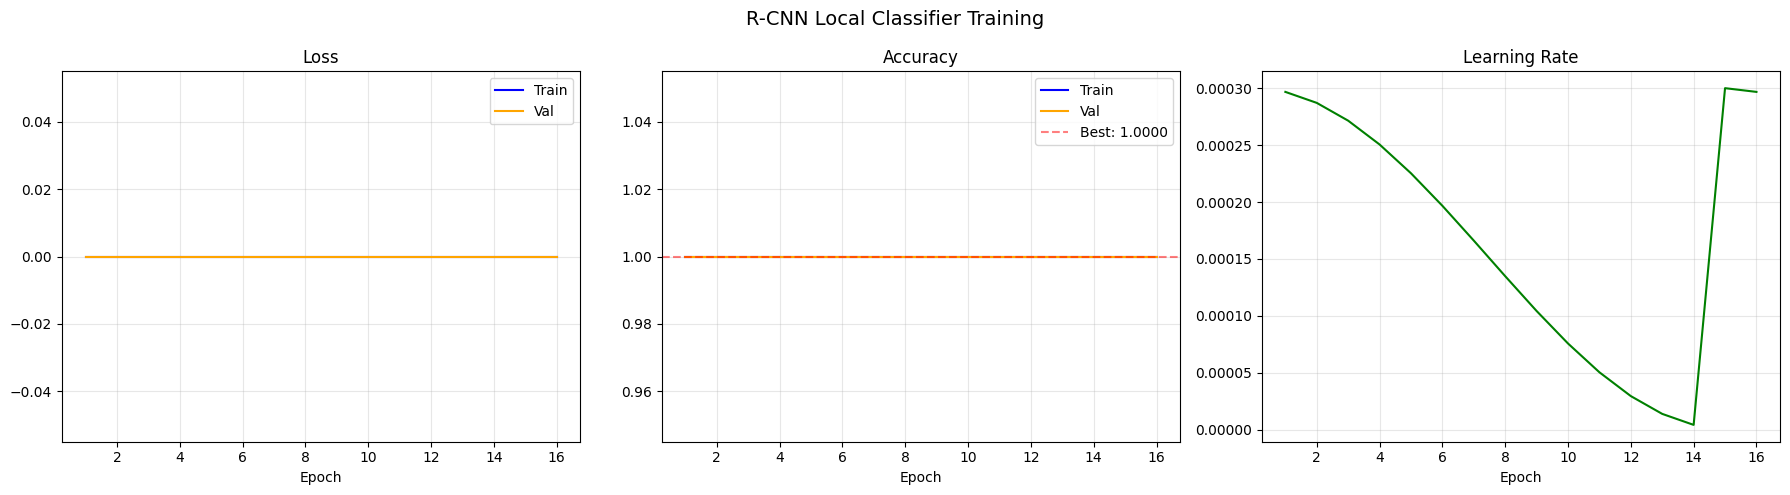

In [10]:
# ============================================================
# CELL 9: Plot Training History
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], label='Train', color='blue')
axes[0].plot(ep_range, history['val_loss'], label='Val', color='orange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, history['train_acc'], label='Train', color='blue')
axes[1].plot(ep_range, history['val_acc'], label='Val', color='orange')
axes[1].axhline(y=best_val_acc, color='red', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ep_range, history['lr'], color='green')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('R-CNN Local Classifier Training', fontsize=14)
plt.tight_layout()
plt.show()

R-CNN LOCAL CLASSIFIER — EVALUATION

--- Train ---
  Accuracy: 1.0000 (100.00%)
        Sickle: P=1.0000  R=1.0000  F1=1.0000

--- Val ---
  Accuracy: 1.0000 (100.00%)
        Sickle: P=1.0000  R=1.0000  F1=1.0000

--- Test ---
  Accuracy: 1.0000 (100.00%)
        Sickle: P=1.0000  R=1.0000  F1=1.0000


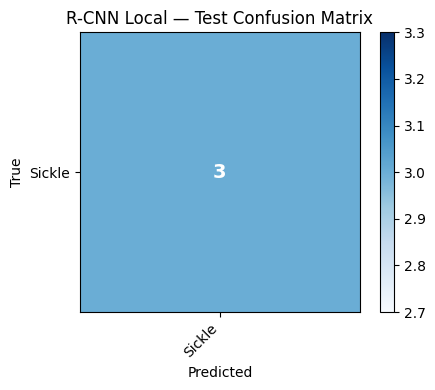

In [11]:
# ============================================================
# CELL 10: Evaluate + Confusion Matrix
# ============================================================

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def confusion_matrix_np(y_true, y_pred, n):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def plot_cm(cm, labels, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(max(5, len(labels)), max(4, len(labels) - 1)))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    ticks = np.arange(len(labels))
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=14, fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# Get class names from ImageFolder
folder_classes = train_dataset.classes
idx_to_class = {i: c for i, c in enumerate(folder_classes)}

print('=' * 60)
print('R-CNN LOCAL CLASSIFIER — EVALUATION')
print('=' * 60)

for split_name, loader in [('Train', train_loader), ('Val', val_loader), ('Test', test_loader)]:
    y_true, y_pred, _ = get_predictions(model, loader, DEVICE)
    acc = (y_true == y_pred).mean()

    print(f'\n--- {split_name} ---')
    print(f'  Accuracy: {acc:.4f} ({acc*100:.2f}%)')

    cm = confusion_matrix_np(y_true, y_pred, n_cls)
    for i, cls_name in enumerate(folder_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
        print(f'  {cls_name:>12}: P={p:.4f}  R={r:.4f}  F1={f1:.4f}')

    if split_name == 'Test':
        plot_cm(cm, folder_classes, title=f'R-CNN Local — {split_name} Confusion Matrix')

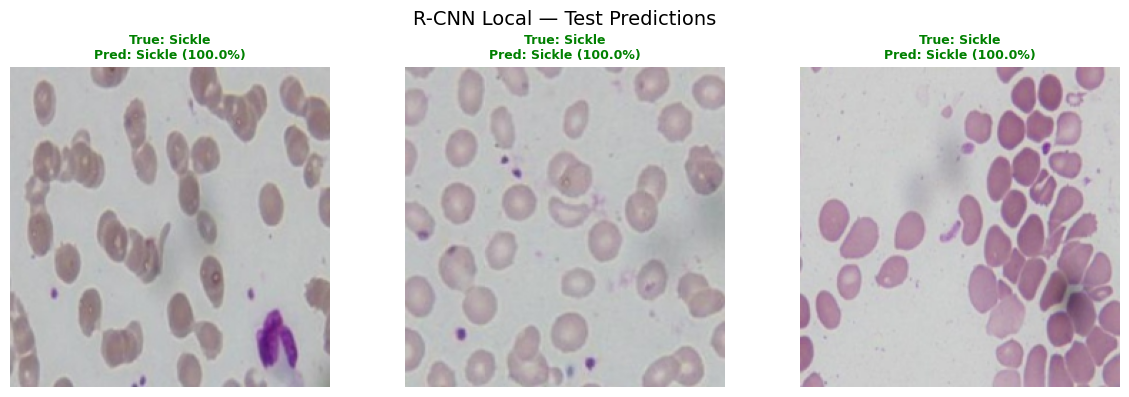

In [12]:
# ============================================================
# CELL 11: Visualize Test Predictions
# ============================================================

def denormalize(tensor):
    t = tensor.clone()
    for ch, m, s in zip(t, IMAGENET_MEAN, IMAGENET_STD):
        ch.mul_(s).add_(m)
    return t.clamp(0, 1)

model.eval()
n_show = min(12, len(test_dataset))
indices = random.sample(range(len(test_dataset)), n_show) if len(test_dataset) > n_show else list(range(len(test_dataset)))

rows = max(1, (n_show + 3) // 4)
cols = min(4, n_show)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).flatten()

for i, idx in enumerate(indices):
    img_tensor, true_label = test_dataset[idx]
    img_display = denormalize(img_tensor).permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(DEVICE))
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        conf = probs[pred_idx].item()

    true_name = idx_to_class[true_label]
    pred_name = idx_to_class[pred_idx]
    color = 'green' if pred_idx == true_label else 'red'

    axes[i].imshow(img_display)
    axes[i].set_title(f'True: {true_name}\nPred: {pred_name} ({conf:.1%})',
                       color=color, fontsize=9, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('R-CNN Local — Test Predictions', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CELL 12: Save Final Model
# ============================================================

model.eval()
model_cpu = model.to('cpu')

FINAL_PATH = os.path.join(MODEL_SAVE_DIR, 'scd_rcnn_local_classifier.pt')
torch.save(model_cpu, FINAL_PATH)

print(f'Model saved: {FINAL_PATH}')
print(f'File size: {os.path.getsize(FINAL_PATH) / 1024 / 1024:.1f} MB')

# Verify
loaded = torch.load(FINAL_PATH, weights_only=False)
loaded.eval()
loaded = loaded.to(DEVICE)

imgs, lbls = next(iter(test_loader))
with torch.no_grad():
    out = loaded(imgs.to(DEVICE))
    probs = torch.softmax(out, dim=1)
    _, preds = out.max(1)

print(f'Output shape: {out.shape}')
print(f'Predictions: {[idx_to_class[p] for p in preds.cpu().tolist()]}')
print(f'True labels: {[idx_to_class[l.item()] for l in lbls]}')
print(f'\nscd_rcnn_local_classifier.pt is ready.')

Model saved: /content/drive/MyDrive/SCD/scd_rcnn_local_classifier.pt
File size: 50.9 MB
Output shape: torch.Size([3, 1])
Predictions: ['Sickle', 'Sickle', 'Sickle']
True labels: ['Sickle', 'Sickle', 'Sickle']

scd_rcnn_local_classifier.pt is ready.
